In [11]:
import pandas as pd

In [12]:
dataset = pd.read_csv("housing.csv")

In [13]:
dataset.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-120.5222,35.0100,42,11595,3434,2766,1030,2.4505,INLAND,337388
1,-114.6337,34.8716,21,8824,1672,3214,1030,2.8002,INLAND,243715
2,-116.8690,41.0688,37,14594,2453,3113,985,2.2798,INLAND,258598
3,-118.2317,34.8957,27,13456,2635,5828,1501,3.4953,NEAR OCEAN,447002
4,-122.7555,35.1063,52,1035,141,361,100,10.6388,NEAR OCEAN,500000


Shape: Dataset mein kitni rows aur columns hain, ye batata hai.


In [14]:
dataset.shape 
#  2000 rows and 10 columns

(2000, 10)

In [16]:
dataset.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='str')

Data Types Check
Isse pata chalega:

float
int
object

In [17]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           2000 non-null   float64
 1   latitude            2000 non-null   float64
 2   housing_median_age  2000 non-null   int64  
 3   total_rooms         2000 non-null   int64  
 4   total_bedrooms      2000 non-null   int64  
 5   population          2000 non-null   int64  
 6   households          2000 non-null   int64  
 7   median_income       2000 non-null   float64
 8   ocean_proximity     2000 non-null   str    
 9   median_house_value  2000 non-null   int64  
dtypes: float64(3), int64(6), str(1)
memory usage: 156.4 KB


Missing Values
Isse har column mein missing values count hongi.

In [18]:
dataset.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

Missing values ko fill karna ,
Hum total_bedrooms ki missing values ko median se fill karenge.

In [19]:
dataset["total_bedrooms"].median()

np.float64(1509.0)

Matlab dataset ka median total bedrooms around 435 hai.

** Missing values fill karo  new CELL

In [20]:
dataset["total_bedrooms"] = dataset["total_bedrooms"].fillna(
    dataset["total_bedrooms"].median()
)

iska matlab Jahan total_bedrooms missing hai, wahan total_bedrooms ka median daal do.

Check again

In [21]:
dataset.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

X aur y separate karna.

Ab hum model ko batayenge ki kaun sa data input hai aur kya predict karna hai.

In [22]:
y = dataset["median_house_value"]

In [23]:
X = dataset.drop(columns=["median_house_value"])
y = dataset["median_house_value"]

Simple meaning
X = Input Features
y = Target / Output

ab hum X and y ko Training and  Testing data me divide krenge.

                 Dataset
                    ↓
          ┌─────────┴─────────┐
          ↓                   ↓
     Training Data        Testing Data
        80%                  20%
          ↓                   ↓
    ANN learns          ANN is checked

Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train → ANN ko input denge
y_train → ANN ko actual answer denge

X_test  → baad mein testing ke liye
y_test  → actual answer, jisse prediction compare karenge

Check karne ke liye 

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1600, 9)
X_test: (400, 9)
y_train: (1600,)
y_test: (400,)


Feature Scaling

Hamare features ki values bahut different range me hain:


ANN ke liye ye different ranges problem create kar sakti hain. Isliye hum data ko similar scale par laayenge.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [28]:
scaler = StandardScaler()

Training data ko scale karo

In [29]:
X_train.dtypes

longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms          int64
population              int64
households              int64
median_income         float64
ocean_proximity           str
dtype: object

In [30]:
print(X_train.select_dtypes(include="object").columns)

Index(['ocean_proximity'], dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_3068\2453056806.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include="object").columns)


In [31]:
X = dataset.drop(columns=["median_house_value"])

y = dataset["median_house_value"]

X = pd.get_dummies(
    X,
    columns=["ocean_proximity"],
    dtype=int
)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='str')


Ab scaling:

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1600, 13)
(400, 13)



Simple flow yaad rakho
CSV
 ↓
Missing values
 ↓
Encoding
 ↓
Train/Test Split
 ↓
Scaling
 ↓
ANN

ANN Model Create Karna


TensorFlow import karo 

TensorFlow deep learning ke liye use hota hai.

In [2]:
import sys
print(sys.executable)

c:\Users\hp\Desktop\House-Price-ANN\.venv-1\Scripts\python.exe


In [35]:
import sys
print(sys.executable)

c:\Users\hp\Desktop\House-Price-ANN\.venv-1\Scripts\python.exe


In [36]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [37]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [38]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

c:\Users\hp\Desktop\House-Price-ANN\.venv-1\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 202239442944.0000 - mae: 443682.4375 - val_loss: 202826678272.0000 - val_mae: 443417.8125
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 202230906880.0000 - mae: 443673.0625 - val_loss: 202810507264.0000 - val_mae: 443400.0000
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 202195763200.0000 - mae: 443634.0625 - val_loss: 202750672896.0000 - val_mae: 443333.8438
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 202083581952.0000 - mae: 443510.1875 - val_loss: 202579607552.0000 - val_mae: 443145.1562
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 201800826880.0000 - mae: 443197.7500 - val_loss: 202184245248.0000 - val_mae: 442709.2500
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 201206726656.0000 - mae: 442539.0625 - val_loss: 201411035136.0000 - val_mae: 441855.8438
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 200121270272.0000 - mae: 441336.5000 - val_loss: 20

In [42]:
loss, mae = model.evaluate(
    X_test_scaled,
    y_test
)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6384130560.0000 - mae: 66425.8672  
Test Loss (MSE): 6384130560.0
Test MAE: 66425.8671875


In [43]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:5])

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
[[373941.5 ]
 [232225.19]
 [308862.38]
 [433010.25]
 [315937.75]]


In [44]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:5],
    "Predicted Price": y_pred[:5].flatten()
})

comparison

,Actual Price,Predicted Price
0,348271,373941.5000
1,313530,232225.1875
2,320983,308862.3750
3,500000,433010.2500
4,266435,315937.7500


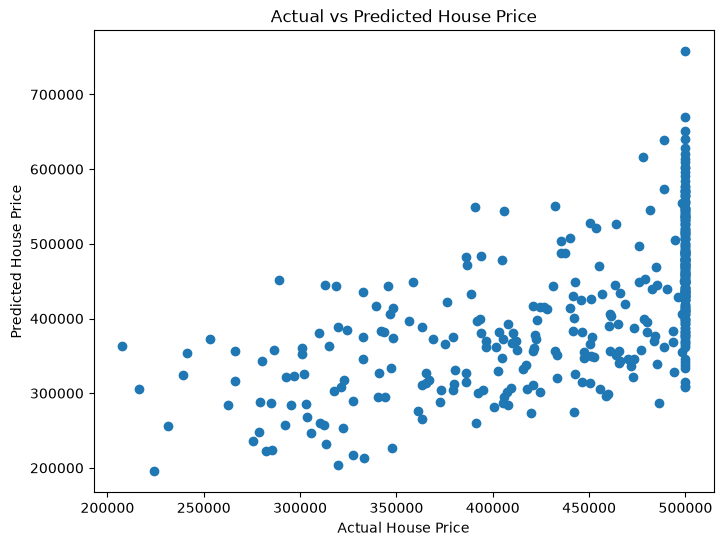

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")

plt.show()

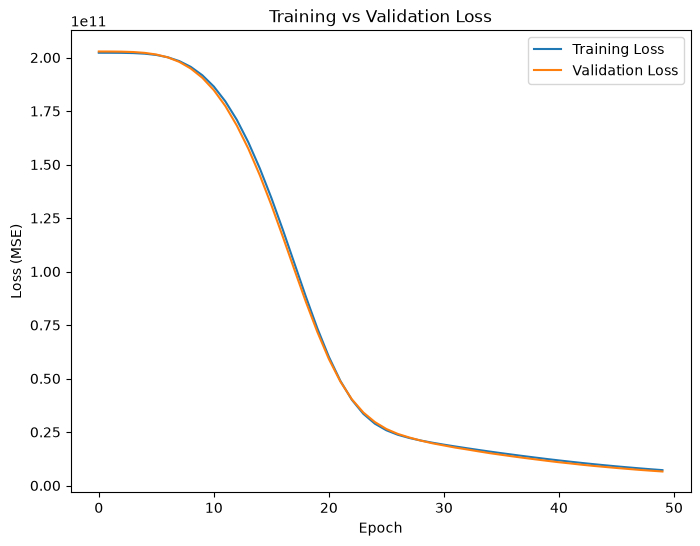

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [51]:
model.save("house_price_model.keras")

In [52]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']